In [2]:
# 图片保存格式控制选项
# 在这里设置是否保存各种格式的图片

# ===== 基本设置 =====
SAVE_PNG = False    # 保存为PNG格式
SAVE_PDF = True    # 保存为PDF格式  
SAVE_EPS = True    # 保存为EPS格式
def save_fig(plt, base_path):
    if SAVE_PNG:
        plt.savefig(
            f"{base_path}.png",
            dpi=300,
            bbox_inches="tight",
            facecolor="white",
        )

    if SAVE_PDF:
        plt.savefig(
            f"{base_path}.pdf",
            bbox_inches="tight",
            facecolor="white",
        )

    if SAVE_EPS:
        plt.savefig(
            f"{base_path}.eps",
            bbox_inches="tight",
            facecolor="white",
            transparent=True,
        )


# 图表一
Issuer侧的开销

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import json
from matplotlib.ticker import ScalarFormatter, FuncFormatter
import seaborn as sns

In [4]:
def setup_seaborn_style():
    """设置seaborn风格"""
    sns.set_theme(style="whitegrid")
    # sns.set_theme()
    sns.set_context("paper")
    
    plt.rcParams["figure.figsize"] = (14, 9)
    plt.rcParams["font.size"] = 14
    plt.rcParams["font.family"] = "DejaVu Sans"
    plt.rcParams["axes.grid"] = True
    plt.rcParams["grid.alpha"] = 0.3
    plt.rcParams["axes.spines.right"] = False
    plt.rcParams["axes.spines.top"] = False

    # seaborn风格的配色方案
    return sns.color_palette("deep", n_colors=10)

In [5]:
def set_boarder(ax):
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['top'].set_linewidth(1)
    ax.spines['right'].set_linewidth(1)
    ax.spines['bottom'].set_linewidth(1)
    ax.spines['left'].set_linewidth(1)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


数据中的最大持续时间: 48.82 秒
向上取整到10的倍数: 50 秒
设置y轴范围上限为: 53.82 秒


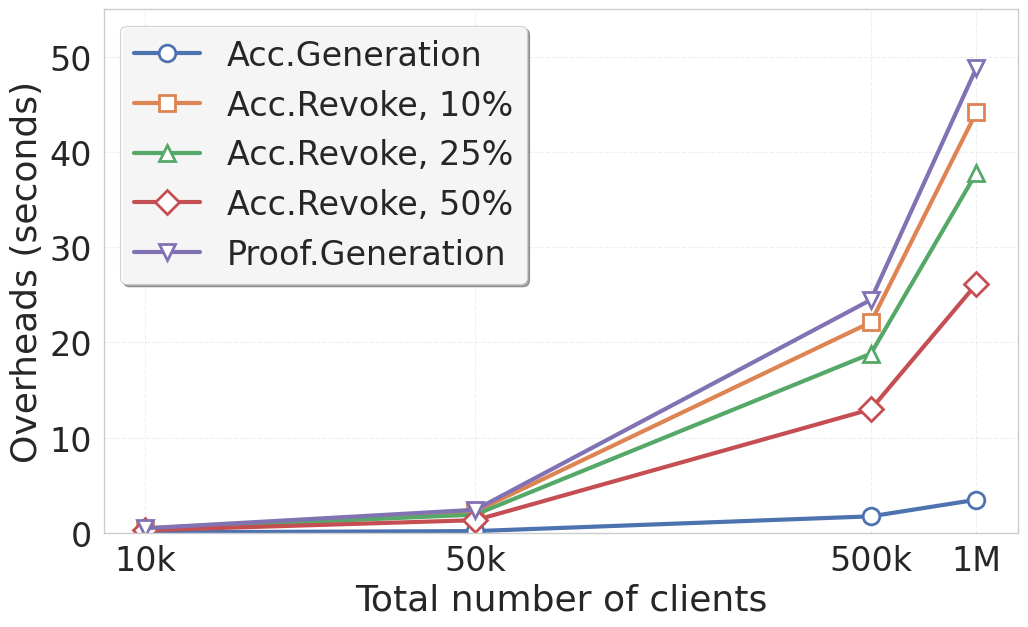

Data extracted for the following experiment categories:
  - Acc.Generation
  - Acc.Revoke, 10%
  - Acc.Revoke, 25%
  - Acc.Revoke, 50%
  - Proof.Generation
Y-axis ticks: [0, 10, 20, 30, 40, 50]
Max duration tick (rounded up to nearest 10): 50s
Plot y-axis max: 55.0s


In [6]:
# 设置seaborn风格
figsize = (10.5, 6.5)
legendFontSize = 24
labelFontSize = 26
labelTickFontSize = 24
linewidth = 3
markersize = 12
colors = setup_seaborn_style()

# 读取基准测试结果
with open("benchmark_results.json", "r") as f:
    batch_data = json.load(f)

# 自动提取所有实验类别和元素数量
experiment_labels = set()
element_counts = set()
all_durations = []  # 存储所有持续时间数据

# 从数据中提取所有唯一的实验类别和元素数量
for key in batch_data["metrics"].keys():
    if "_" in key:
        parts = key.split("_")
        # 提取实验类别（包含可能的逗号和空格）
        label = "_".join(parts[:-1])  # 最后一部分是元素数量
        element_count = int(parts[-1])  # 最后一部分是元素数量

        experiment_labels.add(label)
        element_counts.add(element_count)
        
        # 提取持续时间数据并转换为秒
        duration_ms = batch_data["metrics"][key]["duration_ms"]
        duration_sec = duration_ms / 1000.0
        all_durations.append(duration_sec)

# 转换为排序的列表
experiment_labels = sorted(list(experiment_labels))
element_counts = sorted(list(element_counts))

# 计算y轴范围
max_duration = max(all_durations) if all_durations else 0
y_max = max_duration + 5  # 最大值加5

# 将最大值向上取整到10的倍数
max_duration_ceil_10 = int(np.ceil(max_duration / 10)) * 10

print(f"数据中的最大持续时间: {max_duration:.2f} 秒")
print(f"向上取整到10的倍数: {max_duration_ceil_10} 秒")
print(f"设置y轴范围上限为: {y_max:.2f} 秒")

# 生成横轴标签
x_labels = []
for count in element_counts:
    if count >= 1_000_000:
        x_labels.append(f"{count // 1_000_000}M")
    elif count >= 1000:
        x_labels.append(f"{count // 1000}k")
    else:
        x_labels.append(str(count))
x_positions = np.log10(element_counts)

# 创建图表
fig, ax = plt.subplots(figsize=figsize)

# 定义标记样式（支持动态数量的实验类别）
markers = ["o", "s", "^", "D", "v", "<", ">", "p", "*", "h"]

# 为每个实验类别收集数据
for i, label in enumerate(experiment_labels):
    y_values = []

    # 为10k和50k提取数据
    for count in element_counts:
        key = f"{label}_{count}"
        if key in batch_data["metrics"]:
            metric = batch_data["metrics"][key]
            # 将毫秒转换为秒
            y_values.append(metric["duration_ms"] / 1000.0)
        else:
            y_values.append(None)

    # 只绘制有效数据点
    valid_x = []
    valid_y = []
    for x, y in zip(x_positions, y_values):
        if y is not None:
            valid_x.append(x)
            valid_y.append(y)

    if valid_y:
        ax.plot(
            valid_x,
            valid_y,
            color=colors[i],
            marker=markers[i],
            linewidth=linewidth,
            markersize=markersize,
            label=label,
            markerfacecolor="white",
            markeredgewidth=2,
        )

# 设置坐标轴
ax.set_xscale("log")
# 只显示我们指定的横轴刻度，隐藏其他刻度
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, fontsize=labelTickFontSize)
ax.set_xlabel("Total number of clients", fontsize=labelFontSize)
# 隐藏次要刻度
ax.xaxis.set_minor_formatter(plt.NullFormatter())
ax.tick_params(axis="x", which="minor", bottom=False)

# 纵轴使用线性坐标
ax.set_ylabel("Overheads (seconds)", fontsize=labelFontSize)

# 智能生成y轴刻度，确保相邻刻度间至少有3个数据点
def generate_smart_ticks(data_points, max_value, min_points_per_interval=3):
    """智能生成刻度，确保相邻刻度间至少有指定数量的数据点"""
    if not data_points:
        return [0, max_value]
    
    sorted_data = sorted(data_points)
    n_points = len(sorted_data)
    
    # 尝试不同的间隔大小
    candidates = []
    
    # 尝试常见的间隔大小：1, 2, 5, 10, 20, 50...
    base_intervals = [1, 2, 5, 10, 20, 50, 100]
    for base in base_intervals:
        if base >= max_value:
            continue
            
        ticks = list(range(0, int(max_value) + base, base))
        if max_value > ticks[-1]:
            ticks.append(int(max_value))
        
        # 检查每个间隔的数据点数量
        valid_intervals = True
        for i in range(len(ticks) - 1):
            lower, upper = ticks[i], ticks[i + 1]
            count = sum(1 for point in sorted_data if lower <= point < upper)
            if count < min_points_per_interval and lower > 0:  # 允许0-第一个刻度区间少于3个点
                valid_intervals = False
                break
        
        if valid_intervals:
            candidates.append((base, ticks))
    
    # 选择最佳候选项（间隔最大且总刻度数合理）
    if candidates:
        best_base, best_ticks = max(candidates, key=lambda x: x[0])
        return best_ticks
    else:
        # 如果没有合适的候选项，使用默认逻辑
        if max_value <= 20:
            return list(range(0, int(max_value) + 5, 5))
        elif max_value <= 50:
            return list(range(0, int(max_value) + 10, 10))
        else:
            return list(range(0, int(max_value) + 20, 20))

# 生成智能刻度
y_major_ticks = generate_smart_ticks(all_durations, max_duration_ceil_10)

# 确保包含0和向上取整的最大值
if 0 not in y_major_ticks:
    y_major_ticks.insert(0, 0)
if max_duration_ceil_10 not in y_major_ticks:
    y_major_ticks.append(max_duration_ceil_10)

y_major_ticks = sorted(list(set(y_major_ticks)))  # 去重并排序

# 确保y轴范围足够大以包含所有刻度
plot_y_max = max(y_max, max_duration_ceil_10 + 5)

ax.set_yticks(y_major_ticks)
ax.set_yticklabels([str(int(t)) for t in y_major_ticks], fontsize=labelTickFontSize)

# 设置坐标轴范围 - 使用计算的最大值
ax.set_ylim(0, plot_y_max)

# 添加边框
set_boarder(ax)

# seaborn风格的网格已通过sns.set_theme自动设置
ax.grid(True, linestyle="--", alpha=0.3)

# 添加图例
legend = ax.legend(
    loc='best', fontsize=legendFontSize, frameon=True, ncol = 1, fancybox=True, shadow=True
)
legend.get_frame().set_facecolor("white")
legend.get_frame().set_alpha(0.9)

# 设置y轴格式
ax.yaxis.set_major_formatter(ScalarFormatter())

# 调整布局
plt.tight_layout()

# 根据开关设置保存图片
base_path = "issuer_overheads"
saved_formats = []

save_fig(plt, base_path)
# 显示图表
plt.show()

print("Data extracted for the following experiment categories:")
for label in experiment_labels:
    print(f"  - {label}")
print(f"Y-axis ticks: {y_major_ticks}")
print(f"Max duration tick (rounded up to nearest 10): {max_duration_ceil_10}s")
print(f"Plot y-axis max: {plot_y_max:.1f}s")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


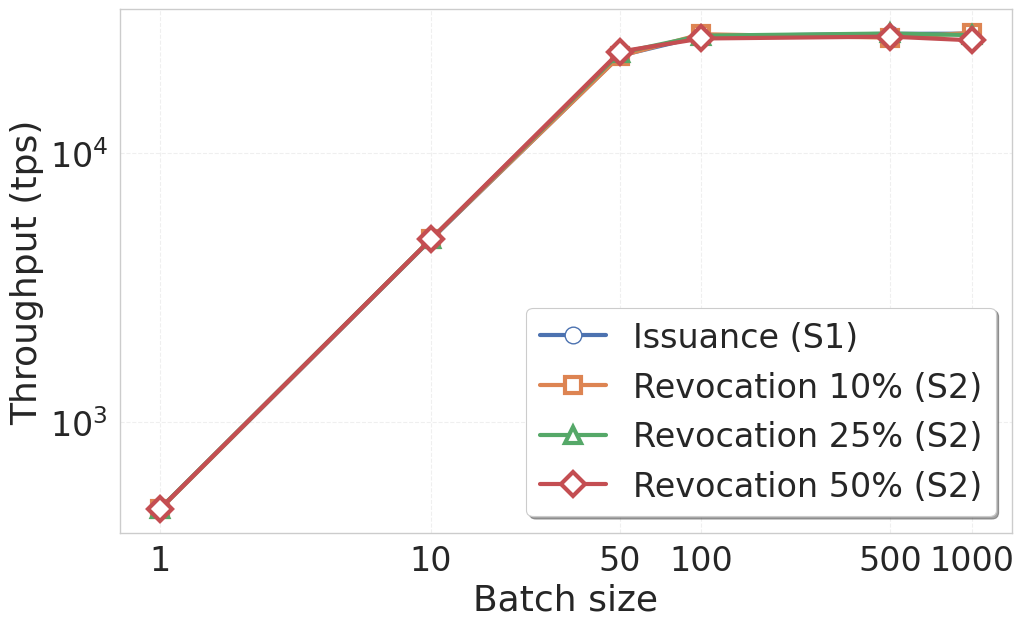

In [7]:
# 图表二：批量处理性能分析 - Throughput
colors = setup_seaborn_style()

# 读取批量基准测试结果
with open("batch_benchmark_results.json", "r") as f:
    batch_data = json.load(f)

# 提取S1签发测试数据
def extract_s1_throughput_data(data):
    """提取S1签发测试的吞吐量数据"""
    s1_data = {}
    for key, metric in data["metrics"].items():
        if key.startswith("S1-Issuance_") and "throughput_ops_per_sec" in metric:
            batch_size = int(key.split("_")[1])
            if metric["throughput_ops_per_sec"] is not None:
                s1_data[batch_size] = metric["throughput_ops_per_sec"]
    return s1_data

# 提取S2撤销测试数据
def extract_s2_throughput_data(data):
    """提取S2撤销测试的吞吐量数据，按撤销比例分组"""
    s2_data = {"10%": {}, "25%": {}, "50%": {}}
    for key, metric in data["metrics"].items():
        if key.startswith("S2-Revoke") and "throughput_ops_per_sec" in metric:
            # 解析类似 "S2-Revoke10%_100" 的key
            if "_" in key:
                parts = key.split("_")
                scenario = parts[0]  # 如 "S2-Revoke10%"
                batch_size = int(parts[1])
                
                # 提取百分比
                if "S2-Revoke10%" in scenario:
                    percentage = "10%"
                elif "S2-Revoke25%" in scenario:
                    percentage = "25%"
                elif "S2-Revoke50%" in scenario:
                    percentage = "50%"
                else:
                    continue
                    
                if metric["throughput_ops_per_sec"] is not None:
                    s2_data[percentage][batch_size] = metric["throughput_ops_per_sec"]
    return s2_data

# 提取S3并发验证测试数据
def extract_s3_throughput_data(data):
    """提取S3并发验证测试的吞吐量数据，按撤销比例分组"""
    s3_data = {"10%": {}, "25%": {}, "50%": {}}
    for key, metric in data["metrics"].items():
        if key.startswith("S3-Concurrent") and "throughput_ops_per_sec" in metric:
            # 解析类似 "S3-Concurrent-10%_100" 的key
            if "_" in key:
                parts = key.split("_")
                scenario = parts[0]  # 如 "S3-Concurrent-10%"
                batch_size = int(parts[1])
                
                # 提取百分比
                if "S3-Concurrent-10%" in scenario:
                    percentage = "10%"
                elif "S3-Concurrent-25%" in scenario:
                    percentage = "25%"
                elif "S3-Concurrent-50%" in scenario:
                    percentage = "50%"
                else:
                    continue
                    
                if metric["throughput_ops_per_sec"] is not None:
                    s3_data[percentage][batch_size] = metric["throughput_ops_per_sec"]
    return s3_data

# 创建单个图表
fig, ax = plt.subplots(figsize=(10.5, 6.5))

# 提取数据
s1_data = extract_s1_throughput_data(batch_data)
s2_data = extract_s2_throughput_data(batch_data)
s3_data = extract_s3_throughput_data(batch_data)

# ========== S1签发测试数据 ==========
if s1_data:
    batch_sizes_s1 = sorted(s1_data.keys())
    throughputs_s1 = [s1_data[bs] for bs in batch_sizes_s1]
    
    ax.plot(batch_sizes_s1, throughputs_s1, 'o-', color=colors[0], linewidth=3, 
                markersize=12, markerfacecolor='white', 
                label='Issuance (S1)')

# ========== S2撤销测试数据 ==========
revocation_colors = {"10%": colors[1], "25%": colors[2], "50%": colors[3]}
revocation_markers = {"10%": "s", "25%": "^", "50%": "D"}

for percentage, color in revocation_colors.items():
    if percentage in s2_data and s2_data[percentage]:
        batch_sizes_s2 = sorted(s2_data[percentage].keys())
        throughputs_s2 = [s2_data[percentage][bs] for bs in batch_sizes_s2]
        
        ax.plot(batch_sizes_s2, throughputs_s2, 
                marker=revocation_markers[percentage], 
                linestyle='-', color=color, linewidth=3,
                markersize=12, markerfacecolor='white', markeredgewidth=3,
                label=f'Revocation {percentage} (S2)')

# ========== S3并发验证测试数据 ==========
verification_colors = {"10%": colors[4], "25%": colors[5], "50%": colors[6]}
verification_markers = {"10%": "v", "25%": "<", "50%": ">"}
verification_linestyles = {"10%": "--", "25%": "-.", "50%": ":"}

for percentage, color in verification_colors.items():
    if percentage in s3_data and s3_data[percentage]:
        batch_sizes_s3 = sorted(s3_data[percentage].keys())
        throughputs_s3 = [s3_data[percentage][bs] for bs in batch_sizes_s3]
        
        ax.plot(batch_sizes_s3, throughputs_s3, 
                marker=verification_markers[percentage], 
                linestyle=verification_linestyles[percentage], color=color, linewidth=linewidth,
                markersize=12, markerfacecolor='white', markeredgewidth=3,
                label=f'Concurrent Verification {percentage} (S3)')

# 添加边框
set_boarder(ax)

# 设置图表属性
ax.set_xscale('log')  # x轴使用对数坐标
ax.set_yscale('log')  # y轴使用对数坐标
ax.set_xlabel('Batch size', fontsize=26)
ax.set_ylabel('Throughput (tps)', fontsize=26)

# seaborn风格的网格已通过sns.set_theme自动设置
ax.grid(True, linestyle='--', alpha=0.3)

# 设置x轴刻度（对数坐标）
all_batch_sizes = set()
if s1_data:
    all_batch_sizes.update(s1_data.keys())
for rev_data in s2_data.values():
    all_batch_sizes.update(rev_data.keys())
for ver_data in s3_data.values():
    all_batch_sizes.update(ver_data.keys())

all_batch_sizes = sorted(list(all_batch_sizes))
ax.set_xticks(all_batch_sizes)
ax.set_xticklabels([str(bs) for bs in all_batch_sizes], fontsize=24)
ax.tick_params(axis='y', labelsize=24)

# 添加图例
ax.legend(loc='best', fontsize=24, frameon=True, fancybox=True, shadow=True, ncol=1)

# 调整布局
plt.tight_layout()

# 根据开关设置保存图表
base_path = "e2e_batch_size_throughput"
save_fig(plt, base_path)
plt.show()

# 打印关键统计数据

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


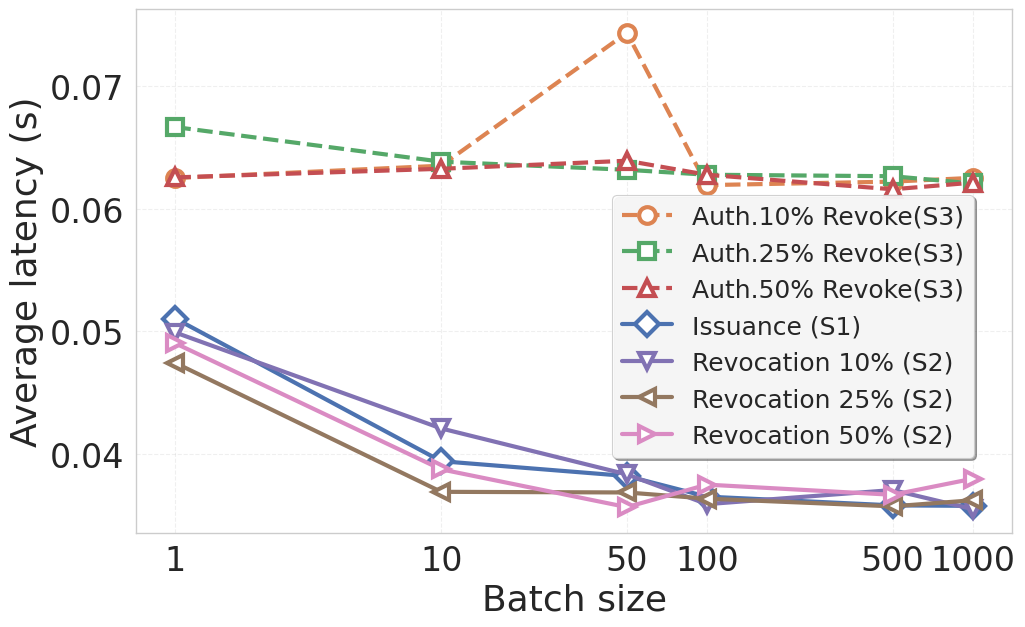

In [8]:
# 图表四：验证性能分析 - 包含批量处理和验证的延迟对比
figsize = (10.5,6.5)
legendFontSize = 8
labelFontSize = 8
labelTickFontSize = 8
linewidth = 3
markersize = 12

with open("verification_results.json", "r") as f:
    verification_data = json.load(f)

# 提取验证latency数据
def extract_verification_latency_data(data):
    """提取验证场景的平均latency数据"""
    verification_latency_data = {}
    for key, metric in data["metrics"].items():
        if "avg_latency_ms" in metric and "Verification" in key:
            # 解析key提取batch_size和scenario
            # 格式如: "S3-Concurrent-10%-Verification_500"
            if "_" in key:
                parts = key.split("_")
                batch_size = int(parts[-1])
                scenario = "_".join(parts[:-1])
                
                avg_latency = metric["avg_latency_ms"]
                
                if scenario not in verification_latency_data:
                    verification_latency_data[scenario] = {}
                
                verification_latency_data[scenario][batch_size] = avg_latency
    
    return verification_latency_data

# 提取批量处理latency数据（非验证）
def extract_batch_latency_data(data):
    """提取批量处理场景的平均latency数据（排除验证）"""
    batch_latency_data = {}
    for key, metric in data["metrics"].items():
        if "avg_latency_ms" in metric and "Verification" not in key:
            # 解析key提取batch_size和scenario
            if "_" in key:
                parts = key.split("_")
                batch_size = int(parts[-1])
                scenario = "_".join(parts[:-1])
                
                avg_latency = metric["avg_latency_ms"]
                
                if scenario not in batch_latency_data:
                    batch_latency_data[scenario] = {}
                
                batch_latency_data[scenario][batch_size] = avg_latency
    
    return batch_latency_data

# 创建图表
fig, ax = plt.subplots(figsize=figsize)

# 提取数据
verification_latency_data = extract_verification_latency_data(verification_data)
batch_latency_data = extract_batch_latency_data(batch_data)

# 合并所有batch_size用于x轴
all_batch_sizes = set()
for data_dict in [verification_latency_data, batch_latency_data]:
    for scenario in data_dict:
        all_batch_sizes.update(data_dict[scenario].keys())
all_batch_sizes = sorted(list(all_batch_sizes))

# 定义颜色和标记
colors_extended = setup_seaborn_style()

# 验证场景的配置
verification_scenarios = {
    'S3-Concurrent-10%-Verification': {
        'color': colors_extended[1], 
        'marker': 'o', 
        'label': 'Auth.10% Revoke(S3)',
        'linestyle': '--'
    },
    'S3-Concurrent-25%-Verification': {
        'color': colors_extended[2], 
        'marker': 's', 
        'label': 'Auth.25% Revoke(S3)',
        'linestyle': '--'
    },
    'S3-Concurrent-50%-Verification': {
        'color': colors_extended[3], 
        'marker': '^', 
        'label': 'Auth.50% Revoke(S3)',
        'linestyle': '--'
    }
}

# 批量处理场景的配置
batch_scenarios = {
    'S1-Issuance-Batch': {
        'color': colors_extended[0], 
        'marker': 'D', 
        'label': 'Issuance (S1)',
        'linestyle': '-'
    },
    'S2-Revoke10%-Batch': {
        'color': colors_extended[4], 
        'marker': 'v', 
        'label': 'Revocation 10% (S2)',
        'linestyle': '-'
    },
    'S2-Revoke25%-Batch': {
        'color': colors_extended[5], 
        'marker': '<', 
        'label': 'Revocation 25% (S2)',
        'linestyle': '-'
    },
    'S2-Revoke50%-Batch': {
        'color': colors_extended[6], 
        'marker': '>', 
        'label': 'Revocation 50% (S2)',
        'linestyle': '-'
    }
}

# 绘制验证场景曲线（虚线）
for scenario in sorted(verification_latency_data.keys()):
    if scenario in verification_scenarios:
        config = verification_scenarios[scenario]
        batch_sizes = sorted(verification_latency_data[scenario].keys())
        latencies = [verification_latency_data[scenario][bs] for bs in batch_sizes]
        
        ax.plot(
            batch_sizes,
            latencies,
            color=config['color'],
            marker=config['marker'],
            linestyle=config['linestyle'],
            linewidth=linewidth,
            markersize=markersize,
            label=config['label'],
            markerfacecolor='white',
            markeredgewidth=3,
        )

# 绘制批量处理场景曲线（实线）
for scenario in sorted(batch_latency_data.keys()):
    if scenario in batch_scenarios:
        config = batch_scenarios[scenario]
        batch_sizes = sorted(batch_latency_data[scenario].keys())
        latencies = [batch_latency_data[scenario][bs] for bs in batch_sizes]
        
        ax.plot(
            batch_sizes,
            latencies,
            color=config['color'],
            marker=config['marker'],
            linestyle=config['linestyle'],
            linewidth=3,
            markersize=12,
            label=config['label'],
            markerfacecolor='white',
            markeredgewidth=3,
        )

# 添加边框
set_boarder(ax)

# 设置坐标轴
ax.set_xscale('log')
ax.set_xticks(all_batch_sizes)
ax.set_xticklabels([str(bs) for bs in all_batch_sizes], fontsize=24)
ax.set_xlabel('Batch size', fontsize=26)
ax.set_ylabel('Average latency (s)', fontsize=26)

# seaborn风格的网格
ax.grid(True, linestyle='--', alpha=0.3)
ax.tick_params(axis='y', labelsize=24)

# 添加图例
legend = plt.legend(
    loc='lower right', 
    bbox_to_anchor=(0.97, 0.12),
    fontsize=18,
    frameon=True, 
    fancybox=True, 
    shadow=True,
    ncol=1,
    # title='Scenarios (Dashed: Client Verification, Solid: Client Request Processing)'
)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.9)

# 调整布局
plt.tight_layout()

# 根据开关设置保存图表
base_path = "e2e_batch_size_latency"
saved_formats = []

save_fig(plt, base_path)
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


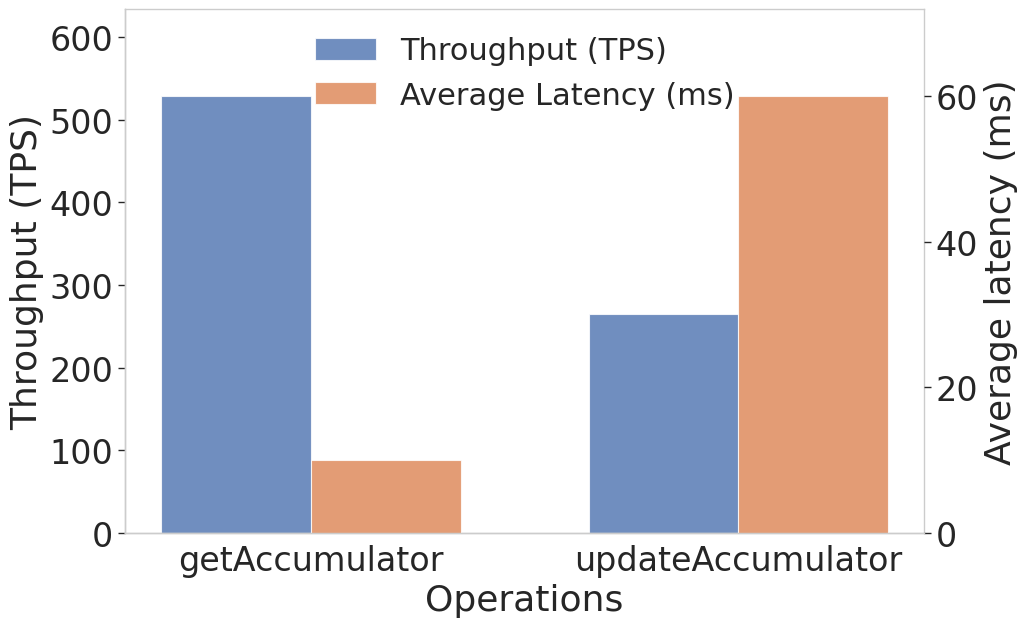

In [9]:
"""创建性能图表"""
# 设置seaborn风格
colors = setup_seaborn_style()

# 性能数据
operations = ['getAccumulator', 'updateAccumulator']
throughput = [528.3, 264.3]  # TPS
avg_latency = [10, 60]       # milliseconds

# 创建图表和主坐标轴
fig, ax1 = plt.subplots(figsize=(10.5,6.5))

x_pos = np.arange(len(operations))
width = 0.35

# ===== 吞吐量柱状图 (左y轴) =====
bars1 = ax1.bar(x_pos - width/2, throughput, width, label='Throughput (TPS)',
                color=colors[0], alpha=0.8)

# 设置左y轴
ax1.set_ylabel('Throughput (TPS)', fontsize=26)
ax1.tick_params(axis='y', labelsize=24)
ax1.set_ylim(0, max(throughput) * 1.2)

# ===== 延迟柱状图 (右y轴) =====
ax2 = ax1.twinx()
ax2.grid(False)
bars2 = ax2.bar(x_pos + width/2, avg_latency, width, label='Average Latency (ms)',
                color=colors[1], alpha=0.8)

# 设置右y轴
ax2.set_ylabel('Average latency (ms)', fontsize=26)
ax2.tick_params(axis='y', labelsize=24)
ax2.set_ylim(0, max(avg_latency) * 1.2)

# 在延迟柱子上添加数值标签
# for bar, value in zip(bars2, avg_latency):
#     height = bar.get_height()
#     ax2.text(bar.get_x() + bar.get_width()/2., height + 2,
#             f'{value:.0f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# 设置x轴
ax1.set_xticks(x_pos)
ax1.set_xticklabels(operations, fontsize=24)
ax1.set_xlabel("Operations", fontsize=26)

# 移除网格
ax1.grid(False)

# 添加边框
set_boarder(ax1)

# 添加图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', fontsize=22, frameon=False)

# 调整布局
plt.tight_layout()

# 保存图表
base_path = "smart_contract"
saved_formats = []

save_fig(plt, base_path)
plt.show()
